Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9199 - loss: 0.2581
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9700 - loss: 0.1000
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9767 - loss: 0.0790
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9794 - loss: 0.0660
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9823 - loss: 0.0600
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9912 - loss: 0.0269


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


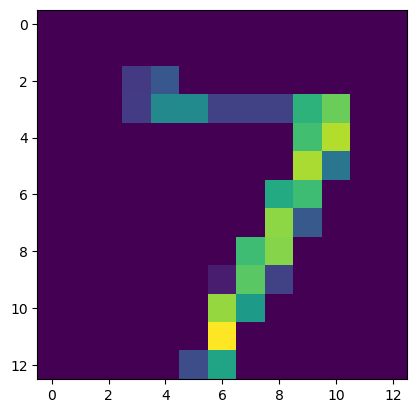

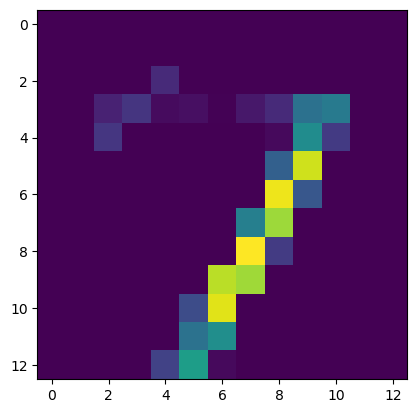

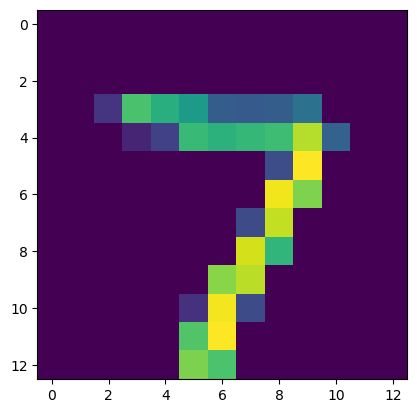

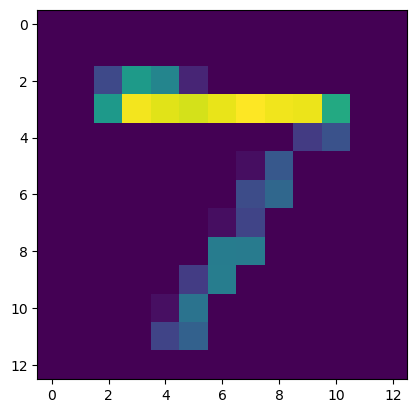

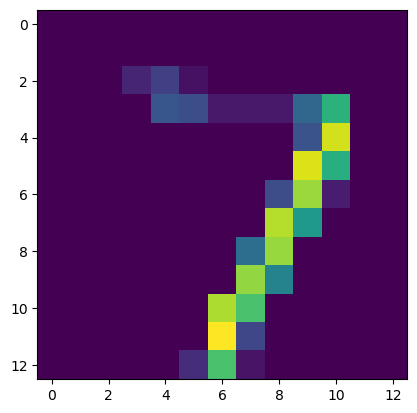

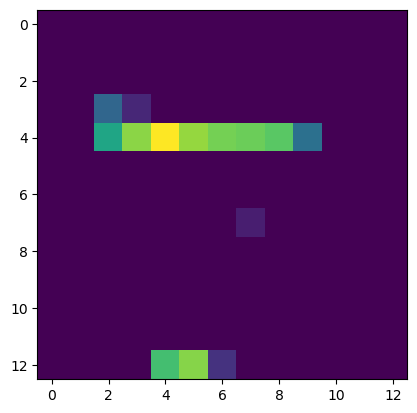

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

model = Sequential()
model.add(InputLayer(shape=(28,28,1)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
# Regularization
model.add(Dropout(0.25))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.fit(x_train,y_train,epochs=5,batch_size=32)

model.evaluate(x_test,y_test)
model.summary()

# Feature Map Visualization
feature_model = Model(inputs=model.inputs,outputs=model.layers[1].output)

feature_maps = feature_model.predict(x_test[:1])

for i in range(6):
    plt.imshow(feature_maps[0,:,:,i])
    plt.show()

# Viva

# Viva Questions and Answers

## 1. What is a Convolutional Neural Network (CNN)?

A Convolutional Neural Network (CNN) is a deep learning model used for image classification and feature extraction. It automatically learns features such as edges, textures, and shapes from images.

---

## 2. Why is CNN preferred over a traditional Neural Network?

* Requires fewer parameters
* Automatically extracts features
* Better accuracy for image processing
* Reduces overfitting through parameter sharing

---

## 3. What is a Convolution Layer?

A convolution layer applies filters (kernels) to the input image to extract important features such as edges, corners, and textures.

---

## 4. What is a Filter (Kernel)?

A filter is a small matrix (e.g., 3×3) that slides over the input image to detect specific patterns.

---

## 5. What is a Feature Map?

A feature map is the output produced after applying a convolution filter to an image. Each filter generates one feature map representing a specific feature.

---

## 6. Why are Feature Maps Visualized?

Feature maps help us understand what features the CNN has learned, such as edges, curves, and textures, making the model more interpretable.

---

## 7. What is MaxPooling?

MaxPooling reduces the size of feature maps by selecting the maximum value from each region, reducing computation while preserving important features.

---

## 8. Why is Flatten Layer Used?

The Flatten layer converts multidimensional feature maps into a one-dimensional vector so that they can be passed to Dense layers.

---

## 9. What is a Dense Layer?

A Dense layer is a fully connected layer that performs the final classification using the extracted features.

---

## 10. Why is Softmax Used?

Softmax converts the output into probabilities for multiple classes. The class with the highest probability is selected as the prediction.

---

## 11. Why is ReLU Used?

ReLU introduces non-linearity into the network, speeds up training, and helps overcome the vanishing gradient problem.

---

## 12. Why is Dropout Used?

Dropout is a regularization technique that randomly disables neurons during training to reduce overfitting and improve model generalization.

---

## 13. What is Regularization?

Regularization prevents overfitting by reducing the complexity of the model. Common techniques include Dropout and L2 Regularization.

---

## 14. Why Normalize the Dataset?

Normalization scales pixel values between 0 and 1, improving training speed and model convergence.

---

## 15. Why Reshape the Images?

CNN expects a 4-dimensional input in the form:

```
(Number of Images, Height, Width, Channels)
```

For MNIST:

```
(60000, 28, 28, 1)
```

---

## 16. Why Use `x_test[:1]`?

`x_test[:1]` selects the first test image while maintaining the batch dimension required by the CNN.

Shape:

```
(1, 28, 28, 1)
```

---

## 17. Why Use `feature_maps[0, :, :, i]`?

`feature_maps[0, :, :, i]` selects the **ith feature map** of the **first input image**.

* `0` → First image
* `:` → All rows
* `:` → All columns
* `i` → ith feature map

---

## 18. What is the Purpose of `plt.imshow()`?

`plt.imshow()` displays the feature map as an image, allowing visualization of the learned features.

---

## 19. What Optimizer is Used?

Adam optimizer is used because it provides faster convergence and adaptive learning rates.

---

## 20. What Loss Function is Used?

For MNIST classification:

```
sparse_categorical_crossentropy
```

It is suitable for multi-class classification with integer labels.

---

## 21. What Evaluation Metric is Used?

Accuracy is used to measure the percentage of correctly classified images.

---

## 22. Explain the CNN Workflow.

```
Input Image
      ↓
Convolution
      ↓
ReLU
      ↓
MaxPooling
      ↓
Dropout
      ↓
Flatten
      ↓
Dense
      ↓
Output Layer
      ↓
Prediction
```

---

## 23. Difference Between Feature Map and Filter

| Filter                            | Feature Map                                |
| --------------------------------- | ------------------------------------------ |
| Small matrix used for convolution | Output generated after applying the filter |
| Learns features                   | Represents detected features               |

---

## 24. Why is CNN Better for Image Processing?

CNN automatically extracts spatial features, requires fewer parameters, and provides better accuracy than fully connected neural networks.

---

## 25. What Does the Output Image of a Feature Map Indicate?

* Bright regions → Strong activation (feature detected)
* Dark regions → Weak or no activation (feature not detected)

Each feature map highlights different image characteristics learned by a filter.
